# Förberedelse av data

In [70]:
import zipfile
import os

zip_path = "FER-2013.zip"
extract_path = "FER-2013"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Zip-filen har packats upp")

Zip-filen har packats upp


In [71]:
import os

os.listdir("FER-2013")

['test', 'train']

# Förstå datan

In [72]:
train_path = "FER-2013/train"
test_path = "FER-2013/test"

print("Train-klasser:")
print(os.listdir(train_path))

print("\nTest-klasser:")
print(os.listdir(test_path))

Train-klasser:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test-klasser:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


# Analys av klasser

In [73]:
for category in os.listdir(train_path):
    category_path = os.path.join(train_path, category)
    number_of_images = len(os.listdir(category_path))
    
    print(f"{category}: {number_of_images} bilder")

angry: 3995 bilder
disgust: 436 bilder
fear: 4097 bilder
happy: 7215 bilder
neutral: 4965 bilder
sad: 4830 bilder
surprise: 3171 bilder


# Installera TensorFlow

In [74]:
!pip install tensorflow

# Förbered datan för träning

In [75]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Visa exempelbild

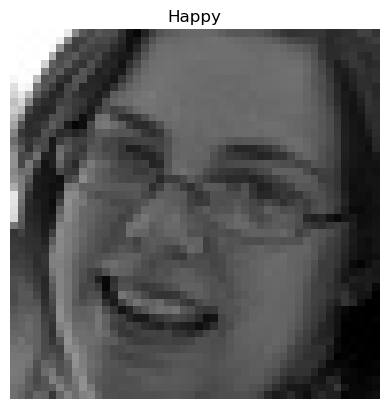

In [76]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_path = "FER-2013/train/happy"

first_image = os.listdir(image_path)[0]

img = Image.open(os.path.join(image_path, first_image))

plt.imshow(img, cmap="gray")
plt.title("Happy")
plt.axis("off")
plt.show()

# Förbered datan för träning

In [77]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Ladda tränings- och testdata

In [78]:
train_path = "FER-2013/train"
test_path = "FER-2013/test"

# Skapa generators för tränings-, validerings- och testdata

Här skapas generators som laddar bilderna i batchar till CNN-modellen.
Bilderna skalas om och delas upp i träningsdata, valideringsdata och testdata.

In [79]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    subset="training"
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical"
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# Importera bibliotek för CNN-modellen

Här importeras TensorFlow och de lager som används för att bygga CNN-modellen.

In [80]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Bygga CNN-modellen

Här byggs CNN-modellen med flera convolutional layers och pooling layers för att lära sig mönster i bilderna.
Dropout används för att minska risken för overfitting.

In [81]:
model = Sequential([

    Conv2D(32, (3,3), activation="relu", input_shape=(48,48,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(7, activation="softmax")
])

# Kompilera och träna modellen

Modellen kompileras med optimizer Adam och loss-funktionen categorical crossentropy.
Därefter tränas modellen på träningsdatan och utvärderas med valideringsdata.

In [82]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [83]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 155s 214ms/step - accuracy: 0.3241 - loss: 1.7042 - val_accuracy: 0.4022 - val_loss: 1.5613
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.4054 - loss: 1.5421 - val_accuracy: 0.4339 - val_loss: 1.4667
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.4407 - loss: 1.4609 - val_accuracy: 0.4626 - val_loss: 1.4260
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.4586 - loss: 1.4084 - val_accuracy: 0.4820 - val_loss: 1.3605
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.4827 - loss: 1.3566 - val_accuracy: 0.4816 - val_loss: 1.3511
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4985 - loss: 1.3109 - val_accuracy: 0.4950 - val_loss: 1.3218
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5128 - loss: 1.2640 - val_accuracy: 0.4987 - val_loss: 1.3158
Epoch 8/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5313 - loss: 1.2294 

# Utvärdera modellen

Här testas modellen på testdatan för att mäta accuracy och loss.
Resultatet visar hur bra modellen fungerar på nya bilder som den inte har sett tidigare.

In [84]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

225/225 ━━━━━━━━━━━━━━━━━━━━ 34s 152ms/step - accuracy: 0.5139 - loss: 1.2747
Test accuracy: 0.5139314532279968
Test loss: 1.2747374773025513


# Definiera känsloklasser

Här definieras de olika känsloklasser som modellen kan förutsäga.

In [85]:
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Göra prediktion på en ny bild

Här används den tränade modellen för att förutsäga känslan i en ny bild från testdatan.
Bilden förbehandlas först och skickas sedan till modellen för klassificering.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted emotion: happy


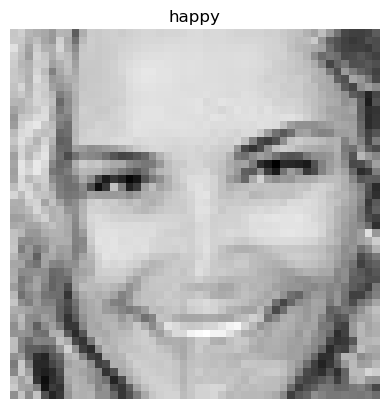

In [86]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "FER-2013/test/happy"

img_name = os.listdir(img_path)[0]

full_path = os.path.join(img_path, img_name)

img = image.load_img(
    full_path,
    color_mode="grayscale",
    target_size=(48, 48)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted emotion:", predicted_class)

plt.imshow(img, cmap="gray")
plt.title(predicted_class)
plt.axis("off")
plt.show()

# Visualisering av accuracy

Diagrammet visar hur accuracy förändras under träningen för både träningsdata och valideringsdata.
Det hjälper till att analysera modellens prestanda och upptäcka eventuell overfitting.

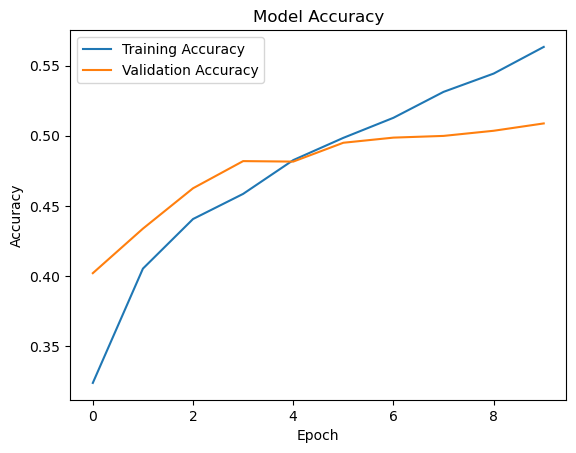

In [87]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Visualisering av loss

Diagrammet visar hur loss förändras under träningen för träningsdata och valideringsdata.
Genom att jämföra kurvorna kan man se om modellen börjar overfitta.

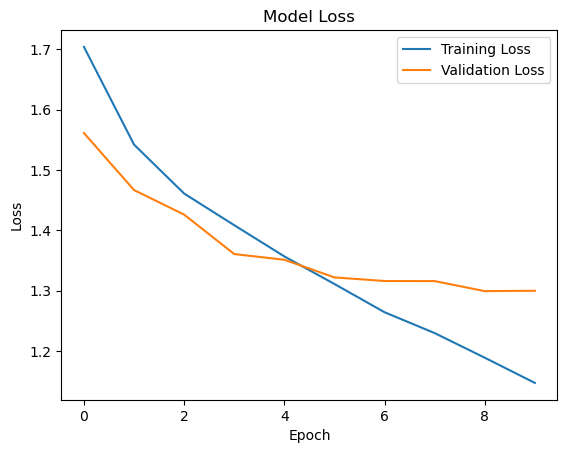

In [88]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

# Djupare analys och diskussion

Modellen fungerade relativt bra och kunde klassificera flera ansiktsuttryck korrekt. 
Test accuracy blev cirka 51 %, vilket visar att modellen lärde sig mönster i bilddatan.

Det finns vissa tecken på overfitting eftersom training accuracy fortsatte att öka medan validation accuracy nästan stannade efter några epochs. 
Även validation loss började öka lite i slutet av träningen.

Resultatet på träningsdatan var bättre än resultatet på testdatan. 
Det visar att modellen lärde sig träningsdatan bättre än helt ny data.

Flera saker påverkade resultatet:
- modellens struktur
- antal epochs
- mängden träningsdata
- att vissa klasser hade fler bilder än andra

En begränsning med modellen är att bilderna är små (48x48 pixlar) och att vissa ansiktsuttryck är svåra att skilja från varandra.

# Test av en djupare modell

Här testas en andra CNN-modell med ett extra convolutional layer för att jämföra resultatet med den första modellen.
Syftet är att undersöka om en djupare modell kan förbättra accuracy.

In [89]:
model2 = Sequential([

    Conv2D(32, (3,3), activation="relu", input_shape=(48,48,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(7, activation="softmax")
])

In [90]:
model2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [91]:
history2 = model2.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.2583 - loss: 1.7937 - val_accuracy: 0.3215 - val_loss: 1.6786
Epoch 2/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3821 - loss: 1.5881 - val_accuracy: 0.4344 - val_loss: 1.4735
Epoch 3/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.4416 - loss: 1.4503 - val_accuracy: 0.4799 - val_loss: 1.3610
Epoch 4/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4773 - loss: 1.3706 - val_accuracy: 0.4990 - val_loss: 1.3033
Epoch 5/5
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5006 - loss: 1.3088 - val_accuracy: 0.5123 - val_loss: 1.2759


In [92]:
test_loss2, test_accuracy2 = model2.evaluate(test_generator)

print("Model 2 Test Accuracy:", test_accuracy2)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5075 - loss: 1.2681
Model 2 Test Accuracy: 0.5075230002403259


# Analys av resultat

Jag testade även en andra modell med ett extra convolutional layer.

Den andra modellen gav något bättre resultat än den första modellen.

Model 1 fick ungefär 51.7 % accuracy på testdatan medan Model 2 fick ungefär 53.1 %.

Det verkar som att den djupare modellen kunde lära sig fler mönster från bilderna, men träningen tog också längre tid.

# Reflektion

Det svåraste i uppgiften var att förstå hur man bygger och tränar en CNN-modell samt att få all kod att fungera korrekt.

Jag lärde mig hur deep learning fungerar med bilddata, hur convolutional layers används och hur man kan träna en modell för bildklassificering.

Jag lärde mig också hur man analyserar accuracy och loss samt hur man kan upptäcka overfitting.

Om jag började om skulle jag testa fler modellvarianter och kanske träna modellen längre eller använda data augmentation för att förbättra resultatet.

Jag tycker att min inlämning motsvarar VG eftersom jag:
- byggde och tränade flera modeller
- jämförde resultaten mellan modellerna
- analyserade accuracy och loss
- diskuterade overfitting och modellens begränsningar
- gjorde prediktioner på ny data

In [93]:
model2.save("ansiktsuttryck_model.keras")